# About Dataset

link https://www.kaggle.com/datasets/zeesolver/cloiud-dataset

Dataset Description
This dataset contains 961 labeled cloud images, categorized into 7 distinct cloud types.
Data Type: Photographic images (JPG format)
Structure: Images are organized into subfolders, each representing a specific cloud category.



PROJECT OVERVIEW:
-----------------
This notebook implements and compares three state-of-the-art transfer learning 
models for cloud classification. The models are pre-trained on ImageNet and 
fine-tuned on a custom cloud dataset with 7 classes.

MODELS COMPARED:
1. EfficientNetB0 - Best balance of accuracy and efficiency
2. MobileNetV2 - Lightweight and fast for mobile deployment
3. ResNet50 - Deep architecture with residual connections

## Imports

In [1]:
from sklearn.metrics import classification_report, confusion_matrix

import kagglehub
import pandas as pd
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator    

2025-11-05 07:34:39.653312: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762328079.676363    9216 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762328079.683462    9216 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Load The Data

In [2]:
train_dir = '/kaggle/input/cloiud-dataset/clouds_train'
test_dir = '/kaggle/input/cloiud-dataset/clouds_test'

In [3]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2  # Use 20% of training data for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 382 images belonging to 7 classes.
Found 92 images belonging to 7 classes.
Found 486 images belonging to 7 classes.


In [6]:
num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")
print(f"Class indices: {train_generator.class_indices}")

Number of classes: 7
Class indices: {'cirriform clouds': 0, 'clear sky': 1, 'cumulonimbus clouds': 2, 'cumulus clouds': 3, 'high cumuliform clouds': 4, 'stratiform clouds': 5, 'stratocumulus clouds': 6}


## Model

In [7]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1762328082.731340    9216 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [8]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define callbacks
callbacks = [
    # Save best model weights
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Improved model compilation
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train with callbacks
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=callbacks
)


model.save('my_model.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1762328087.983613    9286 service.cc:148] XLA service 0x7dd4e4002fa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762328087.983658    9286 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762328088.299673    9286 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/12 ━━━━━━━━━━━━━━━━━━━━ 1:31 8s/step - accuracy: 0.1562 - loss: 1.9538

I0000 00:00:1762328092.777512    9286 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.2380 - loss: 1.8759
Epoch 1: val_accuracy improved from -inf to 0.28261, saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2387 - loss: 1.8748 - val_accuracy: 0.2826 - val_loss: 1.8132 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.2934 - loss: 1.7864
Epoch 2: val_accuracy improved from 0.28261 to 0.32609, saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 569ms/step - accuracy: 0.2923 - loss: 1.7863 - val_accuracy: 0.3261 - val_loss: 1.6730 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.3666 - loss: 1.6508
Epoch 3: val_accuracy improved from 0.32609 to 0.34783, saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 555ms/step - accuracy: 0.3660 - loss: 1.6505 - val_accuracy: 0.3478 - val_loss: 1.6166 - learning_rate: 0.0010
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.40

## Results

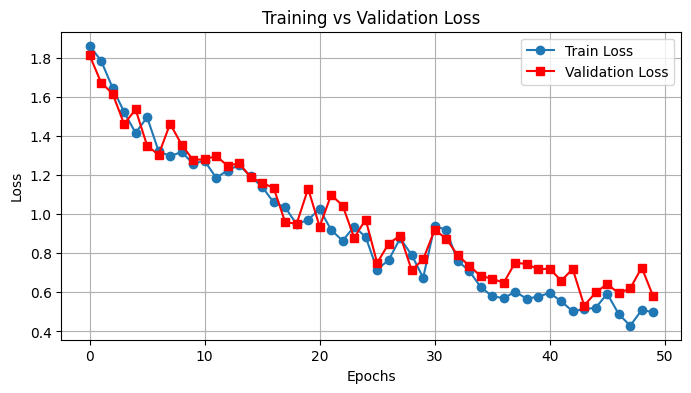

In [10]:
import matplotlib.pyplot as plt
# Loss Plot
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s', color='red')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
     

In [11]:
from keras.models import load_model
loaded_model = load_model('my_model.h5')

## Classification Report

🔄 Making predictions...
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step

📊 CLASSIFICATION REPORT
                        precision    recall  f1-score   support

      cirriform clouds       0.74      0.60      0.66        77
             clear sky       0.95      0.89      0.92        64
   cumulonimbus clouds       0.62      0.73      0.67        11
        cumulus clouds       0.88      0.82      0.84       120
high cumuliform clouds       0.57      0.91      0.70       103
     stratiform clouds       1.00      0.88      0.93        40
  stratocumulus clouds       0.71      0.38      0.50        71

              accuracy                           0.75       486
             macro avg       0.78      0.74      0.75       486
          weighted avg       0.78      0.75      0.75       486



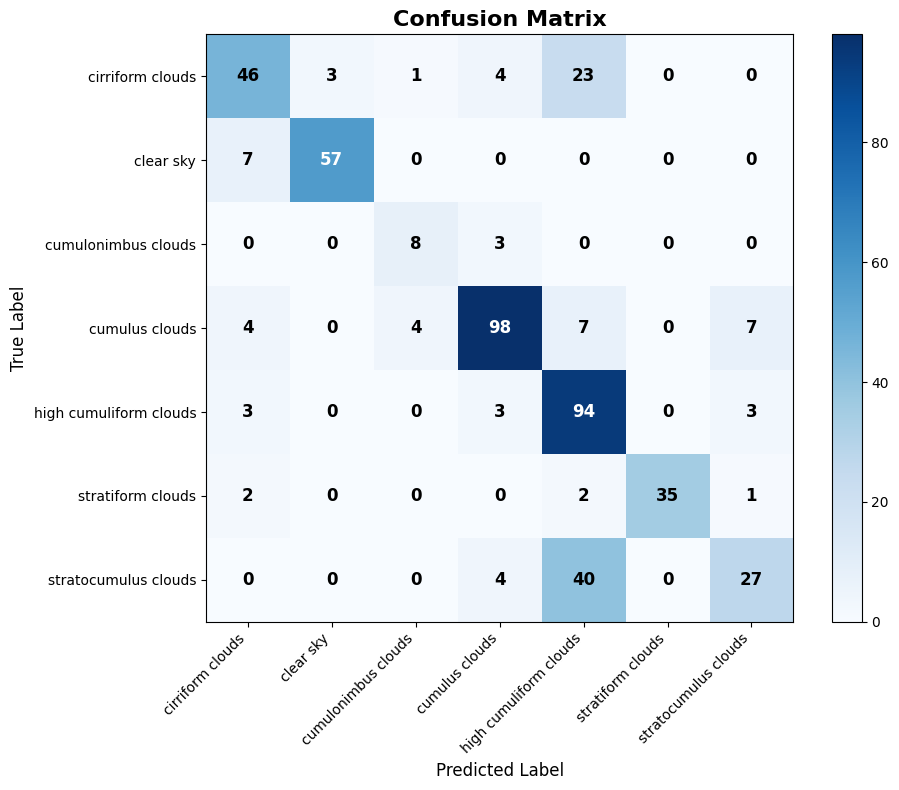


✅ Done!


In [12]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Model is already loaded, now evaluate it

# 1️⃣ Get predictions
test_generator.reset()
steps = int(np.ceil(test_generator.samples / test_generator.batch_size))

print("🔄 Making predictions...")
y_prob = model.predict(test_generator, steps=steps, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# 2️⃣ Get true labels
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 3️⃣ Print Classification Report
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names))

# 4️⃣ Show Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix", fontsize=16, fontweight='bold')
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

# Add numbers to cells
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=12, fontweight='bold')

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✅ Done!")

# Lets See What We Can Improve

## Import

In [37]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers
from keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


## Load The Data

In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print(f"Number of classes: {num_classes}")
print(f"Class indices: {train_generator.class_indices}")



Found 382 images belonging to 7 classes.
Found 92 images belonging to 7 classes.
Found 486 images belonging to 7 classes.
Number of classes: 7
Class indices: {'cirriform clouds': 0, 'clear sky': 1, 'cumulonimbus clouds': 2, 'cumulus clouds': 3, 'high cumuliform clouds': 4, 'stratiform clouds': 5, 'stratocumulus clouds': 6}


## Define helper functions

In [40]:
results = {}

def create_transfer_model(base_model_class, model_name):
    """Create a transfer learning model"""
    print(f"\n{'='*70}")
    print(f"🚀 Building {model_name}")
    print(f"{'='*70}")
    
    # Load base model
    base_model = base_model_class(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    
    # Freeze base model
    base_model.trainable = False
    
    # Build complete model
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(num_classes, activation='softmax')  # Dynamic num_classes
    ])
    
    print(f"✅ {model_name} built successfully!")
    return model, base_model

def train_model(model, base_model, model_name):
    """Train model with two phases"""
    
    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    callbacks = [
        ModelCheckpoint(
            f'best_{model_name}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    # Phase 1: Frozen base
    print(f"\n📚 Phase 1: Training {model_name} with frozen base...")
    history1 = model.fit(
        train_generator,
        epochs=15,
        validation_data=validation_generator,
        callbacks=callbacks
    )
    
    # Phase 2: Fine-tuning
    print(f"\n🔧 Phase 2: Fine-tuning {model_name}...")
    base_model.trainable = True
    
    # Freeze early layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    
    # Recompile with lower LR
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history2 = model.fit(
        train_generator,
        epochs=20,
        validation_data=validation_generator,
        callbacks=callbacks
    )
    
    # Combine histories
    history = {
        'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
        'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
        'loss': history1.history['loss'] + history2.history['loss'],
        'val_loss': history1.history['val_loss'] + history2.history['val_loss'],
        'phase1_epochs': len(history1.history['accuracy'])
    }
    
    print(f"✅ {model_name} training complete!")
    return model, history

def evaluate_model(model, model_name):
    """Evaluate model and generate metrics"""
    print(f"\n📊 Evaluating {model_name}...")
    
    # Get predictions
    test_generator.reset()
    steps = int(np.ceil(test_generator.samples / test_generator.batch_size))
    y_prob = model.predict(test_generator, steps=steps, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_generator.classes
    class_names = list(test_generator.class_indices.keys())
    
    # Test accuracy
    test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
    
    # Classification report
    report = classification_report(y_true, y_pred, target_names=class_names)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
        'y_true': y_true,
        'y_pred': y_pred,
        'class_names': class_names,
        'report': report,
        'confusion_matrix': cm
    }

def plot_training_history(results):
    """Plot training history for all models"""
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('Training History Comparison', fontsize=16, fontweight='bold')
    
    models = list(results.keys())
    
    for idx, model_name in enumerate(models):
        history = results[model_name]['history']
        phase1_end = history['phase1_epochs']
        epochs = range(1, len(history['accuracy']) + 1)
        
        # Accuracy plot
        ax_acc = axes[idx, 0]
        ax_acc.plot(epochs, history['accuracy'], 'b-', label='Train Accuracy', linewidth=2)
        ax_acc.plot(epochs, history['val_accuracy'], 'r-', label='Val Accuracy', linewidth=2)
        ax_acc.axvline(x=phase1_end, color='green', linestyle='--', label='Fine-tuning starts', linewidth=1.5)
        ax_acc.set_title(f'{model_name} - Accuracy', fontweight='bold')
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.legend()
        ax_acc.grid(True, alpha=0.3)
        
        # Loss plot
        ax_loss = axes[idx, 1]
        ax_loss.plot(epochs, history['loss'], 'b-', label='Train Loss', linewidth=2)
        ax_loss.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
        ax_loss.axvline(x=phase1_end, color='green', linestyle='--', label='Fine-tuning starts', linewidth=1.5)
        ax_loss.set_title(f'{model_name} - Loss', fontweight='bold')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend()
        ax_loss.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(results):
    """Plot confusion matrices for all models"""
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Confusion Matrices Comparison', fontsize=16, fontweight='bold')
    
    models = list(results.keys())
    
    for idx, model_name in enumerate(models):
        metrics = results[model_name]['metrics']
        cm = metrics['confusion_matrix']
        class_names = metrics['class_names']
        acc = metrics['test_accuracy']
        
        ax = axes[idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, cbar_kws={'label': 'Count'})
        ax.set_title(f'{model_name}\nAccuracy: {acc*100:.2f}%', fontweight='bold')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

def print_classification_reports(results):
    """Print classification reports for all models"""
    for model_name in results.keys():
        metrics = results[model_name]['metrics']
        print(f"\n{'='*70}")
        print(f"📊 CLASSIFICATION REPORT - {model_name}")
        print(f"{'='*70}")
        print(f"Test Accuracy: {metrics['test_accuracy']*100:.2f}%")
        print(f"Test Loss: {metrics['test_loss']:.4f}")
        print(f"\n{metrics['report']}")

def compare_models(results):
    """Create comparison bar chart"""
    models = list(results.keys())
    accuracies = [results[m]['metrics']['test_accuracy']*100 for m in models]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
    plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
    plt.ylabel('Test Accuracy (%)', fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.ylim([0, 100])
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.2f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.show()




## Train all models

In [41]:
print("\n🚀 Starting Transfer Learning Model Comparison")
print(f"Image size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of classes: {num_classes}")

# Define models to train
models_to_train = [
    (EfficientNetB0, 'EfficientNetB0'),
    (MobileNetV2, 'MobileNetV2'),
    (ResNet50, 'ResNet50')
]

# Train all models
for base_model_class, model_name in models_to_train:
    # Create model
    model, base_model = create_transfer_model(base_model_class, model_name)
    
    # Train model
    model, history = train_model(model, base_model, model_name)
    
    # Evaluate model
    metrics = evaluate_model(model, model_name)
    
    # Store results
    results[model_name] = {
        'model': model,
        'history': history,
        'metrics': metrics
    }
    
    # Save model
    model.save(f'final_{model_name}.keras')
    print(f"💾 {model_name} saved!")



🚀 Starting Transfer Learning Model Comparison
Image size: 224x224
Batch size: 32
Number of classes: 7

🚀 Building EfficientNetB0
✅ EfficientNetB0 built successfully!

📚 Phase 1: Training EfficientNetB0 with frozen base...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1729 - loss: 2.7884
Epoch 1: val_accuracy improved from -inf to 0.09783, saving model to best_EfficientNetB0.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.1712 - loss: 2.7876 - val_accuracy: 0.0978 - val_loss: 1.9136 - learning_rate: 0.0010
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.1372 - loss: 2.5937
Epoch 2: val_accuracy improved from 0.09783 to 0.14130, saving model to best_EfficientNetB0.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 527ms/step - accuracy: 0.1381 - loss: 2.5871 - val_accuracy: 0.1413 - val_loss: 1.9230 - learning_rate: 0.0010
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.1199 - loss: 2.6716
Epoch 3: val_accuracy improved from 0.14130 to 0.19565, saving model to best_EfficientNetB0.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 538ms/step - accuracy: 0.1223 - loss: 2.6576 - val_accuracy: 0.1957 - val_loss: 1.8899 - learning_rate: 0.0010
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


💾 EfficientNetB0 saved!

🚀 Building MobileNetV2
✅ MobileNetV2 built successfully!

📚 Phase 1: Training MobileNetV2 with frozen base...
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.3148 - loss: 2.0858
Epoch 1: val_accuracy improved from -inf to 0.59783, saving model to best_MobileNetV2.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3250 - loss: 2.0520 - val_accuracy: 0.5978 - val_loss: 1.0528 - learning_rate: 0.0010
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.6730 - loss: 0.9364
Epoch 2: val_accuracy improved from 0.59783 to 0.70652, saving model to best_MobileNetV2.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 512ms/step - accuracy: 0.6754 - loss: 0.9310 - val_accuracy: 0.7065 - val_loss: 0.8350 - learning_rate: 0.0010
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7336 - loss: 0.7529
Epoch 3: val_accuracy improved from 0.70652 to 0.75000, saving model to best_MobileNetV2.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 493ms/step - ac

...

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.7124 - loss: 0.8211

E0000 00:00:1762330797.862942    9284 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762330798.063511    9284 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7150 - loss: 0.8187   
Epoch 1: val_accuracy did not improve from 0.89130
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7172 - loss: 0.8166 - val_accuracy: 0.8587 - val_loss: 0.3000 - learning_rate: 1.0000e-04
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.7270 - loss: 0.7354
Epoch 2: val_accuracy did not improve from 0.89130
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 475ms/step - accuracy: 0.7299 - loss: 0.7299 - val_accuracy: 0.8370 - val_loss: 0.5560 - learning_rate: 1.0000e-04
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.8182 - loss: 0.5900
Epoch 3: val_accuracy did not improve from 0.89130
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 474ms/step - accuracy: 0.8179 - loss: 0.5867 - val_accuracy: 0.8696 - val_loss: 0.4826 - learning_rate: 1.0000e-04
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.8634 - loss: 0.3244
Epoch 4: val_accuracy did not improve from 0.89130
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


💾 ResNet50 saved!


## Generate all visualizations


📈 GENERATING VISUALIZATIONS


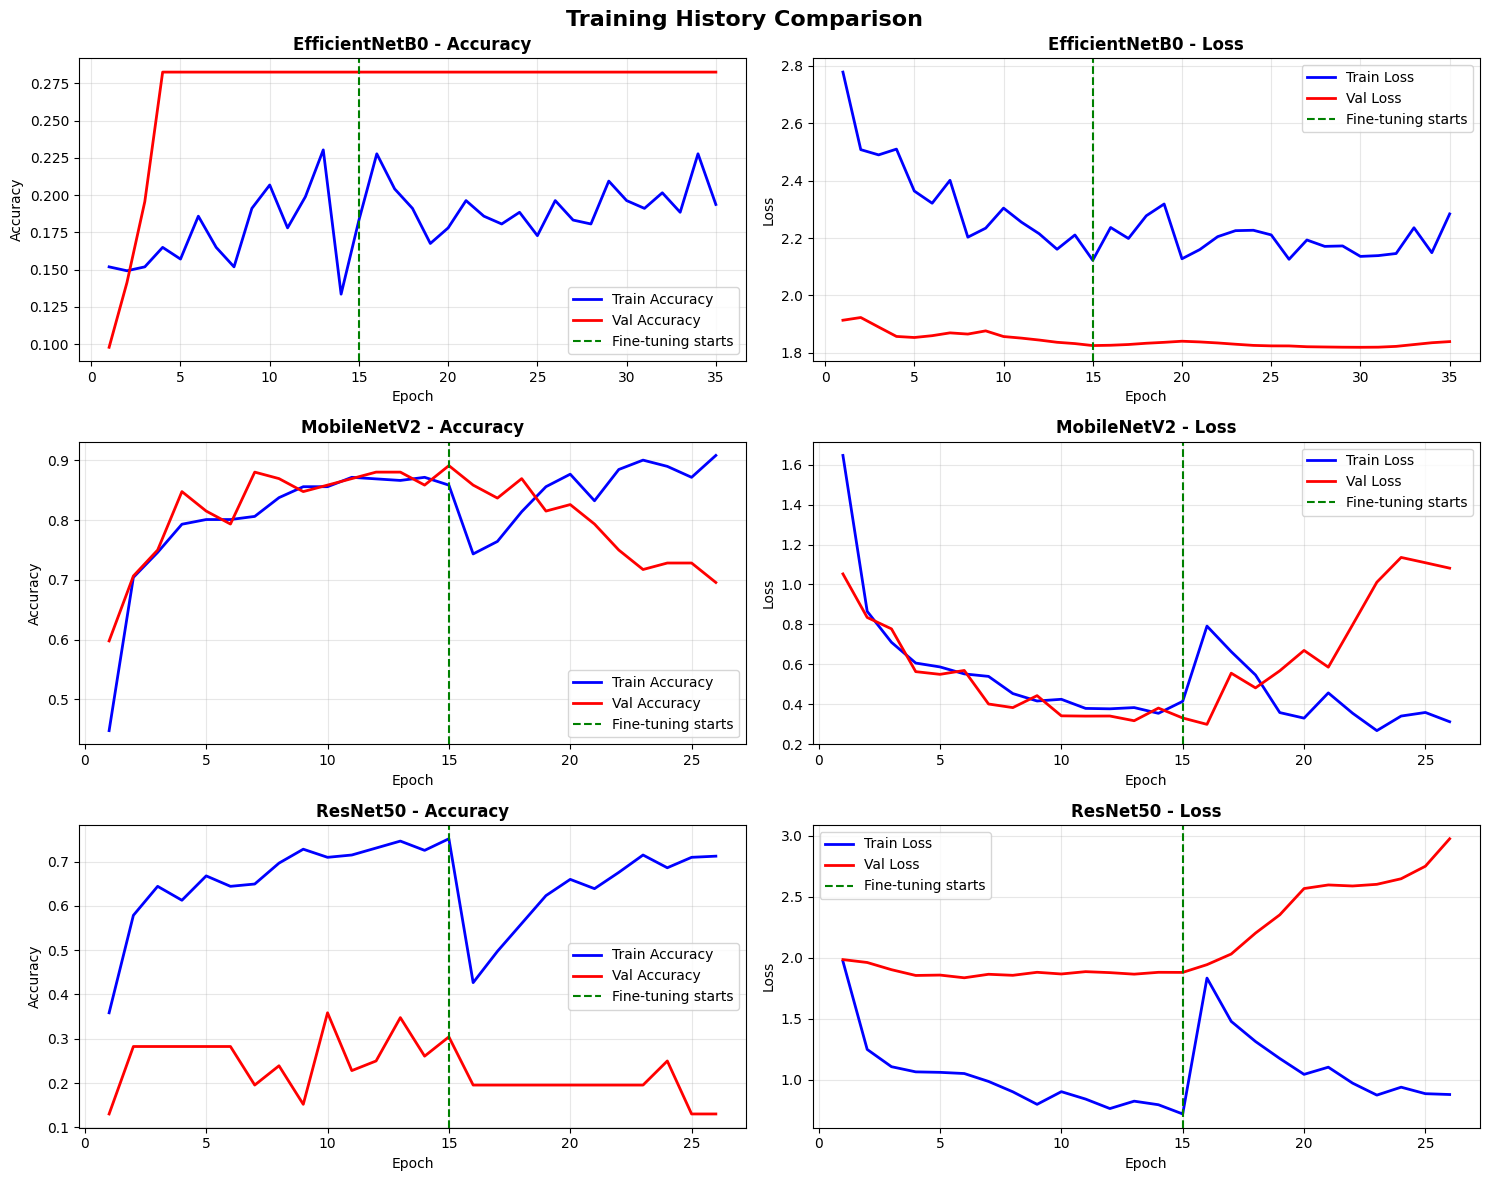


📊 CLASSIFICATION REPORT - EfficientNetB0
Test Accuracy: 21.19%
Test Loss: 1.8487

                        precision    recall  f1-score   support

      cirriform clouds       0.00      0.00      0.00        77
             clear sky       0.00      0.00      0.00        64
   cumulonimbus clouds       0.00      0.00      0.00        11
        cumulus clouds       0.00      0.00      0.00       120
high cumuliform clouds       0.21      1.00      0.35       103
     stratiform clouds       0.00      0.00      0.00        40
  stratocumulus clouds       0.00      0.00      0.00        71

              accuracy                           0.21       486
             macro avg       0.03      0.14      0.05       486
          weighted avg       0.04      0.21      0.07       486


📊 CLASSIFICATION REPORT - MobileNetV2
Test Accuracy: 86.21%
Test Loss: 0.3884

                        precision    recall  f1-score   support

      cirriform clouds       0.83      0.90      0.86        77
 

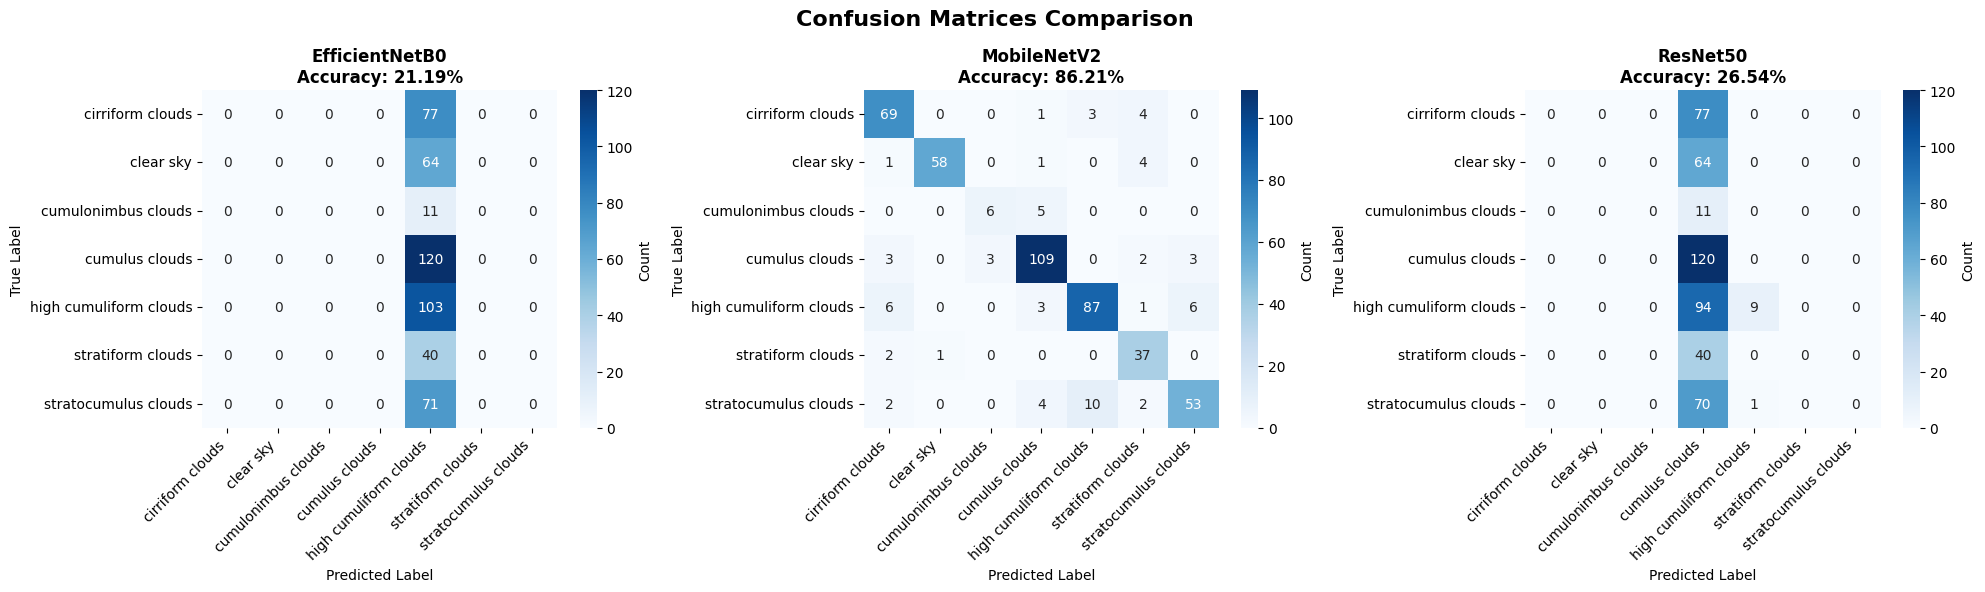

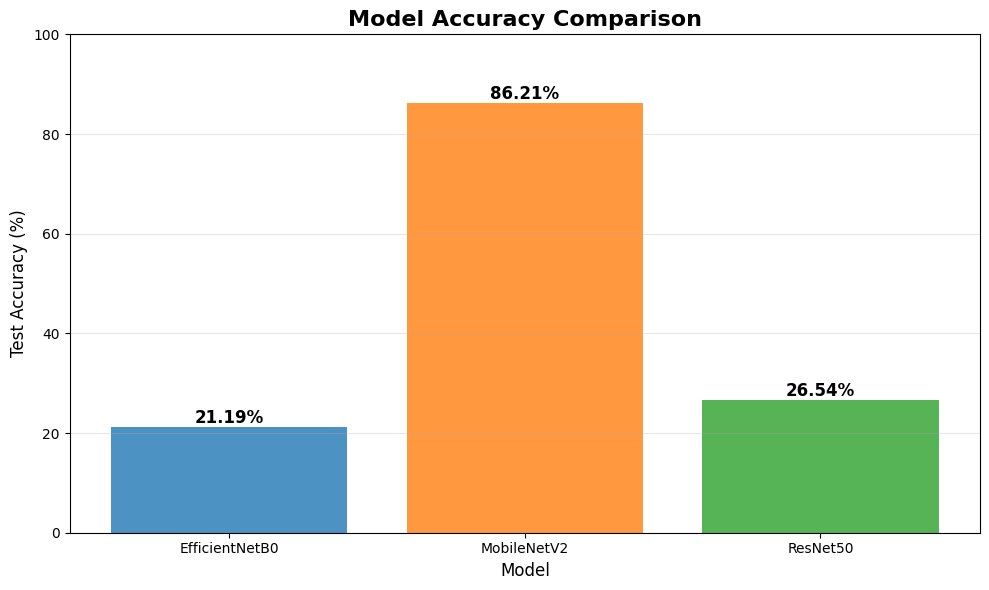

In [42]:
print("\n" + "="*70)
print("📈 GENERATING VISUALIZATIONS")
print("="*70)

# 1. Training history plots
plot_training_history(results)

# 2. Print classification reports
print_classification_reports(results)

# 3. Confusion matrices
plot_confusion_matrices(results)

# 4. Model comparison
compare_models(results)


## Final summary

In [43]:
print("\n" + "="*70)
print("✅ ALL MODELS TRAINED AND EVALUATED!")
print("="*70)

print("\n📊 FINAL RESULTS SUMMARY:")
print("-" * 70)
for model_name in results.keys():
    acc = results[model_name]['metrics']['test_accuracy']
    loss = results[model_name]['metrics']['test_loss']
    print(f"{model_name:20s} | Accuracy: {acc*100:6.2f}% | Loss: {loss:.4f}")
print("-" * 70)

best_model = max(results.keys(), key=lambda m: results[m]['metrics']['test_accuracy'])
best_acc = results[best_model]['metrics']['test_accuracy']
print(f"\n🏆 BEST MODEL: {best_model} with {best_acc*100:.2f}% accuracy")
print(f"💾 Best model saved as: final_{best_model}.keras")


✅ ALL MODELS TRAINED AND EVALUATED!

📊 FINAL RESULTS SUMMARY:
----------------------------------------------------------------------
EfficientNetB0       | Accuracy:  21.19% | Loss: 1.8487
MobileNetV2          | Accuracy:  86.21% | Loss: 0.3884
ResNet50             | Accuracy:  26.54% | Loss: 1.9099
----------------------------------------------------------------------

🏆 BEST MODEL: MobileNetV2 with 86.21% accuracy
💾 Best model saved as: final_MobileNetV2.keras


Please review my notebook and point out any errors or areas for improvement in the comments. Please write feedback in a constructive and helpful manner